In [102]:
import torch
import matplotlib.pyplot as plt
import torchvision

from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchmetrics.classification import MulticlassAccuracy

In [18]:
train_data = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    download = True,
    train = True,
    target_transform = None
)

test_data = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    download = True,
    root = "data",
    train = False,
    target_transform = None
)

In [19]:
len(train_data), len(test_data)

(60000, 10000)

In [32]:
def tanh(x: torch.Tensor) -> torch.Tensor:
    result = (torch.exp(x) - torch.exp(-x) / torch.exp(x) + torch.exp(-x))
    return result

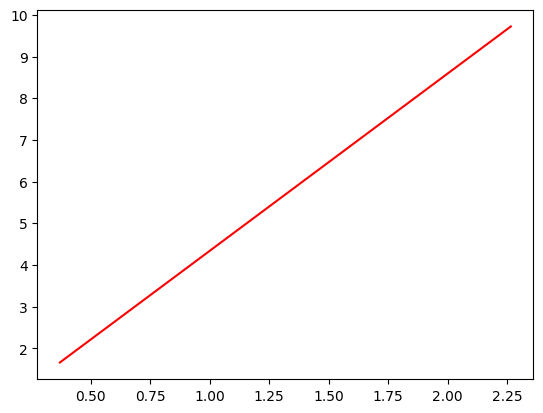

In [34]:
x = torch.randn(2)
y = tanh(x)
plt.plot(x, y, label = "Tanh Function", c="red")

In [20]:
train_data_loader = DataLoader(train_data, shuffle = True, batch_size = 64)
test_data_loader = DataLoader(test_data, shuffle = True, batch_size = 64)

In [28]:
train_classnames = train_data.classes

In [21]:
len(train_data_loader), len(test_data_loader)

(938, 157)

In [22]:
image, target = next(iter(train_data_loader))

In [38]:
image.shape, target[0], len(target.unique())

(torch.Size([64, 1, 28, 28]), tensor(6), 10)

In [35]:
28 * 28

784

Text(0.5, 1.0, 'Shirt')

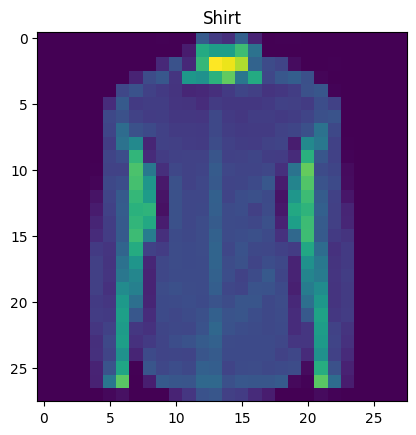

In [30]:
plt.imshow(image[0].squeeze())
plt.title(train_classnames[target[0]])

In [74]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, in_features: int = 784,
                 out_features: int = 10,
                 hidden_units: int = 128,
                 batch_unit: int = 64
        ):
        super(FashionMNISTModel, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_unit: int = batch_unit

        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.batch_unit),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.batch_unit,
                           out_features = self.batch_unit)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [75]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [76]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [77]:
model = FashionMNISTModel(out_features = 10, hidden_units = 128, batch_unit = 64).to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [94]:
test_classnames = test_data.classes
torch.manual_seed(42)

model.eval()
image, target = next(iter(test_data_loader))
single_image = image[0].unsqueeze(1).to(device)

with torch.inference_mode():
    image, target = image.to(device), target.to(device)
    y_logits = model(single_image)
    y_pred = torch.argmax(y_logits, dim = 1)

# plt.imshow(y_logits.squeeze().detach().cpu())
# test_classnames[y_pred.squeeze()]
test_classnames, y_pred

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 tensor([29], device='mps:0'))

In [99]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-5)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [109]:
epochs = 10
total_epochs = []
losses = []
test_losses = []
total_train_accuracy = []
total_test_accuracy = []

for epoch in tqdm(range(epochs)):
    running_loss = 0.0
    running_test_loss = 0.0
    running_accuracy = 0.0
    running_test_accuracy = 0.0

    model.train()
    for idx, (image, target) in enumerate(train_data_loader):
        image, target = image.to(device), target.to(device)
        y_logits = model(image)

        loss = loss_fn(y_logits, target)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        y_true = torch.argmax(y_logits, dim = 1)
        train_accuracy = accuracy_fn(target, y_true)
        running_loss += loss.item()
        running_accuracy += train_accuracy.item()

    avg_train_loss = running_loss / len(train_data_loader)
    avg_train_accuracy = running_accuracy / len(train_data_loader)
    losses.append(loss.item())
    total_train_accuracy.append(train_accuracy.item())

    model.eval()
    with torch.inference_mode():
        for idx, (image, target) in enumerate(test_data_loader):
            image, target = image.to(device), target.to(device)
            test_logits = model(image)

            test_loss = loss_fn(test_logits, target)
            test_pred = torch.argmax(test_logits, dim = 1)
            test_accuracy = accuracy_fn(target, test_pred)

            running_test_loss += test_loss.item()
            running_test_accuracy += test_accuracy.item()

        avg_test_loss = running_test_loss / len(test_data_loader)
        avg_test_accuracy = running_test_accuracy / len(test_data_loader)
        test_losses.append(test_loss.item())
        total_test_accuracy.append(test_accuracy.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Training Loss: {avg_train_loss:.5f} | Accuracy: {avg_train_accuracy:.3f}")
        print(f"Testing Loss: {avg_test_loss:.5f} | Accuracy: {avg_test_accuracy:.3f}")

 10%|████▍                                       | 1/10 [00:13<02:03, 13.69s/it]

Training Loss: 0.33325 | Accuracy: 0.882
Testing Loss: 0.36833 | Accuracy: 0.867


 20%|████████▊                                   | 2/10 [00:25<01:42, 12.82s/it]

Training Loss: 0.31341 | Accuracy: 0.888
Testing Loss: 0.36389 | Accuracy: 0.874


 30%|█████████████▏                              | 3/10 [00:38<01:29, 12.79s/it]

...

Training Loss: 0.24574 | Accuracy: 0.909
Testing Loss: 0.33872 | Accuracy: 0.880


 90%|███████████████████████████████████████▌    | 9/10 [01:55<00:12, 12.81s/it]

Training Loss: 0.23919 | Accuracy: 0.913
Testing Loss: 0.34878 | Accuracy: 0.884


100%|███████████████████████████████████████████| 10/10 [02:08<00:00, 12.84s/it]

Training Loss: 0.23259 | Accuracy: 0.914
Testing Loss: 0.33484 | Accuracy: 0.885


In [124]:
torch.manual_seed(42)

test_classnames = test_data.classes

image, label = next(iter(test_data_loader))
single_image = image[20].to(device)

model.eval()
with torch.inference_mode():
    y_logits = model(single_image)
    y_pred = torch.argmax(y_logits, dim = 1)

# plt.imshow(y_pred.squeeze().detach().cpu())
# y_pred.squeeze().cpu()

# plt.imshow(y_pred.squeeze().cpu())
plt.imgshow(0
test_classnames[label[20]], test_classnames[y_pred]

('Ankle boot', 'Ankle boot')